# FBS Detection — AI Model Benchmark

**Purpose**: Comparative analysis of AI models for False Base Station detection. Each model is also available in its own notebook for detailed analysis:
- **Random Forest** → `fbs_detection_rf.ipynb`
- **XGBoost** → `fbs_detection_xgboost.ipynb`
- **LightGBM** → `fbs_detection_lightgbm.ipynb`
- **CatBoost** → `fbs_detection_catboost.ipynb`
- **Extra Trees** → `fbs_detection_extratrees.ipynb`
- **MLP** → `fbs_detection_mlp.ipynb`

**Benchmark metrics**:
- **Training overhead**: wall-clock time
- **Detection overhead**: inference latency (per-sample, batch)
- **Detection quality**: accuracy, precision, recall, F1, ROC-AUC, MCC

Run `fbs_dataset_analysis.ipynb` first to generate `fbs_train.csv` and `fbs_test.csv`.

In [12]:
import json
import time
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data

In [13]:
TRAIN_PATH = Path("fbs_train.csv")
TEST_PATH  = Path("fbs_test.csv")
CW_PATH    = Path("fbs_class_weights.json")

for p in [TRAIN_PATH, TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run fbs_dataset_analysis.ipynb first.")

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
feature_cols = [c for c in train_df.columns if c not in ("label", "source")]

# Use numpy arrays for XGBoost compatibility
X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df["label"].values
X_test  = test_df[feature_cols].values.astype(np.float32)
y_test  = test_df["label"].values

cw = {int(k): v for k, v in json.load(open(CW_PATH)).items()} if CW_PATH.exists() else "balanced"

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(feature_cols)}")

Train: 5,919 | Test: 1,480 | Features: 762


## 2. Model Definitions

In [14]:
def get_models(class_weight):
    """Return dict of name -> (model, supports_proba)."""
    cw = class_weight if isinstance(class_weight, dict) else "balanced"
    n_est = 200
    return {
        "Random Forest": (RandomForestClassifier(n_estimators=n_est, max_depth=20, min_samples_leaf=3, max_features="sqrt", class_weight=cw, random_state=42, n_jobs=-1), True),
        "XGBoost": (XGBClassifier(n_estimators=n_est, max_depth=6, learning_rate=0.05, min_child_weight=3, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, eval_metric="auc", n_jobs=-1, random_state=42, verbosity=0), True),
        "LightGBM": (LGBMClassifier(n_estimators=n_est, num_leaves=31, max_depth=6, min_child_samples=20, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, class_weight="balanced", n_jobs=-1, random_state=42, verbose=-1), True),
        "CatBoost": (CatBoostClassifier(iterations=n_est, depth=6, learning_rate=0.05, l2_leaf_reg=3.0, min_data_in_leaf=20, subsample=0.8, auto_class_weights="Balanced", random_state=42, verbose=0, task_type="CPU"), True),
        "Extra Trees": (ExtraTreesClassifier(n_estimators=n_est, max_depth=20, min_samples_split=5, min_samples_leaf=3, max_features="sqrt", class_weight=cw, random_state=42, n_jobs=-1), True),
        "MLP": (Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=400, learning_rate="adaptive", early_stopping=True, validation_fraction=0.1, n_iter_no_change=15, alpha=0.01, batch_size=64, random_state=42)),
        ]), True),
    }

## 3. Benchmark Loop — Training & Detection Overhead

In [15]:
def run_benchmark(X_train, y_train, X_test, y_test, class_weight):
    models = get_models(class_weight)
    results = []

    for name, (model, has_proba) in models.items():
        print(f"  Training {name}...", flush=True)
        row = {"model": name}

        # ── Training overhead ──
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        row["train_time_sec"] = time.perf_counter() - t0

        # ── Detection overhead (batch inference) ──
        n_test = len(X_test)
        t0 = time.perf_counter()
        y_pred = model.predict(X_test)
        row["inference_batch_sec"] = time.perf_counter() - t0
        row["inference_ms_per_sample"] = (row["inference_batch_sec"] / n_test) * 1000

        # ── Detection quality ──
        row["accuracy"] = accuracy_score(y_test, y_pred)
        row["precision_macro"] = precision_score(y_test, y_pred, average="macro", zero_division=0)
        row["recall_macro"] = recall_score(y_test, y_pred, average="macro", zero_division=0)
        row["f1_macro"] = f1_score(y_test, y_pred, average="macro", zero_division=0)
        row["mcc"] = matthews_corrcoef(y_test, y_pred)

        if has_proba:
            try:
                y_proba = model.predict_proba(X_test)[:, 1]
                row["roc_auc"] = roc_auc_score(y_test, y_proba)
            except Exception:
                row["roc_auc"] = np.nan
        else:
            row["roc_auc"] = np.nan

        results.append(row)
        print(f"  {name}: train={row['train_time_sec']:.2f}s, infer={row['inference_ms_per_sample']:.3f}ms/sample, acc={row['accuracy']:.4f}, F1={row['f1_macro']:.4f}")

    return pd.DataFrame(results)

In [16]:
print("Running benchmark...")
bench_df = run_benchmark(X_train, y_train, X_test, y_test, cw)
bench_df

Running benchmark...
  Training Random Forest...


  Random Forest: train=0.23s, infer=0.016ms/sample, acc=0.9149, F1=0.9148
  Training XGBoost...
  XGBoost: train=0.35s, infer=0.001ms/sample, acc=0.9142, F1=0.9142
  Training LightGBM...
  LightGBM: train=0.26s, infer=0.002ms/sample, acc=0.9155, F1=0.9155
  Training CatBoost...


/home/ubuntu-chan/Documents/Github/airgap/ai-detection/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu-chan/Documents/Github/airgap/ai-detection/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CatBoost: train=0.57s, infer=0.001ms/sample, acc=0.9115, F1=0.9115
  Training Extra Trees...
  Extra Trees: train=0.19s, infer=0.016ms/sample, acc=0.9101, F1=0.9100
  Training MLP...
  MLP: train=24.47s, infer=0.076ms/sample, acc=0.9115, F1=0.9113


,model,train_time_sec,inference_batch_sec,inference_ms_per_sample,accuracy,precision_macro,recall_macro,f1_macro,mcc,roc_auc
0,Random Forest,0.230071,0.024298,0.016418,0.914865,0.916676,0.914777,0.914760,0.831450,0.962090
1,XGBoost,0.354707,0.001381,0.000933,0.914189,0.914773,0.914139,0.914152,0.828912,0.957425
2,LightGBM,0.259909,0.002614,0.001766,0.915541,0.916514,0.915476,0.915482,0.831990,0.958630
3,CatBoost,0.569587,0.001450,0.000979,0.911486,0.911780,0.911451,0.911465,0.823231,0.958716
4,Extra Trees,0.189281,0.023782,0.016069,0.910135,0.911575,0.910056,0.910044,0.821629,0.953553
5,MLP,24.467922,0.112006,0.075680,0.911486,0.914764,0.911367,0.911294,0.826124,0.956050


## 4. Comparative Tables

In [17]:
# Performance overhead (training & detection)
overhead_cols = ["model", "train_time_sec", "inference_batch_sec", "inference_ms_per_sample"]
overhead_df = bench_df[overhead_cols].copy()
overhead_df["train_time_sec"] = overhead_df["train_time_sec"].round(2)
overhead_df["inference_batch_sec"] = overhead_df["inference_batch_sec"].round(4)
overhead_df["inference_ms_per_sample"] = overhead_df["inference_ms_per_sample"].round(4)
overhead_df.columns = ["Model", "Train (s)", "Inference batch (s)", "Inference (ms/sample)"]
print("=== Performance Overhead ===")
display(overhead_df)

=== Performance Overhead ===


,Model,Train (s),Inference batch (s),Inference (ms/sample)
0,Random Forest,0.23,0.0243,0.0164
1,XGBoost,0.35,0.0014,0.0009
2,LightGBM,0.26,0.0026,0.0018
3,CatBoost,0.57,0.0014,0.0010
4,Extra Trees,0.19,0.0238,0.0161
5,MLP,24.47,0.1120,0.0757


In [18]:
# Detection quality
quality_cols = ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc", "mcc"]
quality_df = bench_df[quality_cols].copy()
quality_df = quality_df.round(4)
quality_df.columns = ["Model", "Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)", "ROC-AUC", "MCC"]
print("=== Detection Quality ===")
display(quality_df)

=== Detection Quality ===


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC,MCC
0,Random Forest,0.9149,0.9167,0.9148,0.9148,0.9621,0.8315
1,XGBoost,0.9142,0.9148,0.9141,0.9142,0.9574,0.8289
2,LightGBM,0.9155,0.9165,0.9155,0.9155,0.9586,0.8320
3,CatBoost,0.9115,0.9118,0.9115,0.9115,0.9587,0.8232
4,Extra Trees,0.9101,0.9116,0.9101,0.9100,0.9536,0.8216
5,MLP,0.9115,0.9148,0.9114,0.9113,0.9560,0.8261


## 5. Comparative Visualizations

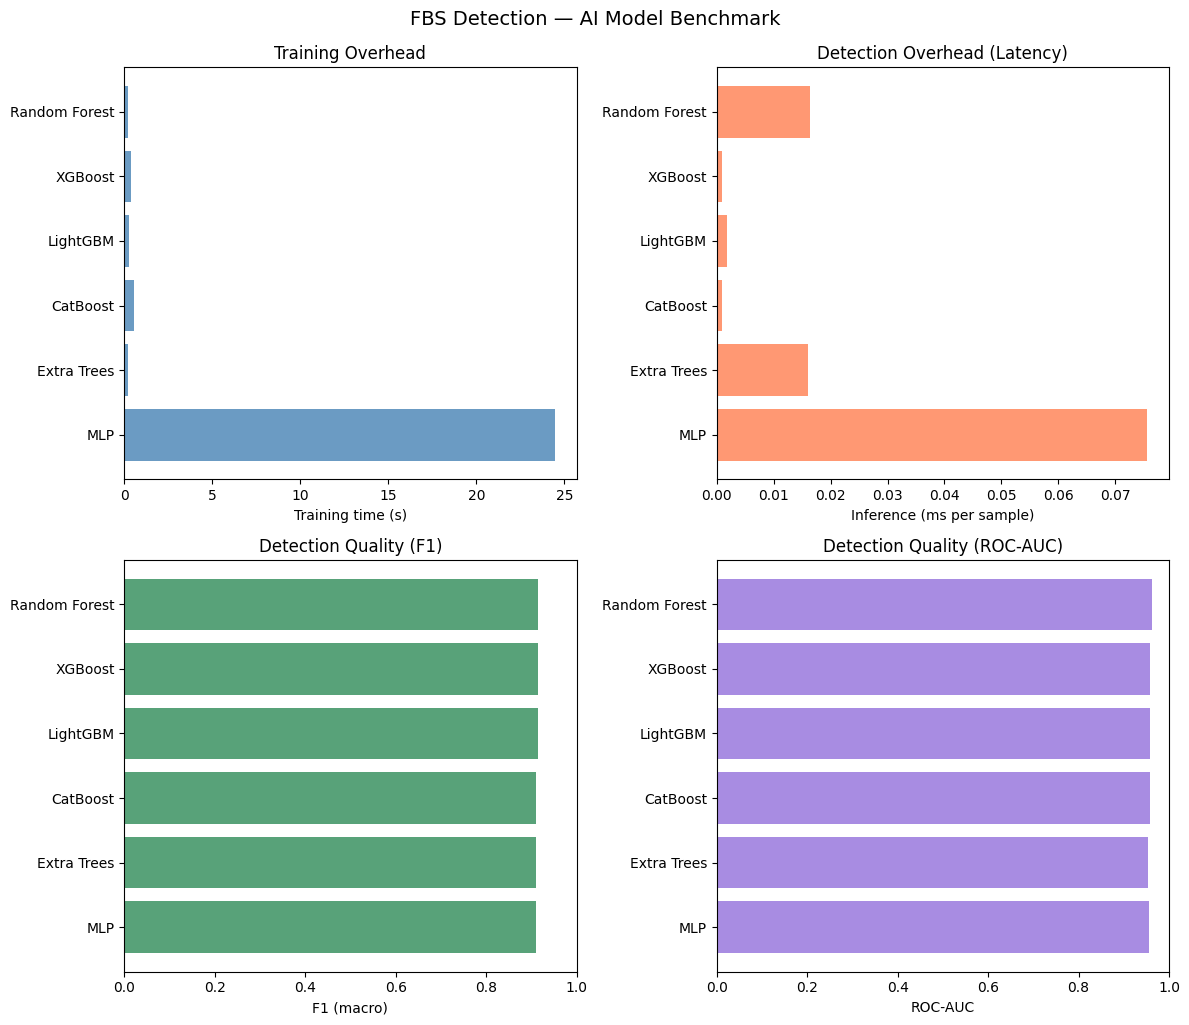

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Training time
ax = axes[0, 0]
ax.barh(bench_df["model"], bench_df["train_time_sec"], color="steelblue", alpha=0.8)
ax.set_xlabel("Training time (s)")
ax.set_title("Training Overhead")
ax.invert_yaxis()

# Inference latency (ms/sample)
ax = axes[0, 1]
ax.barh(bench_df["model"], bench_df["inference_ms_per_sample"], color="coral", alpha=0.8)
ax.set_xlabel("Inference (ms per sample)")
ax.set_title("Detection Overhead (Latency)")
ax.invert_yaxis()

# F1 macro
ax = axes[1, 0]
ax.barh(bench_df["model"], bench_df["f1_macro"], color="seagreen", alpha=0.8)
ax.set_xlabel("F1 (macro)")
ax.set_title("Detection Quality (F1)")
ax.set_xlim(0, 1)
ax.invert_yaxis()

# ROC-AUC
ax = axes[1, 1]
ax.barh(bench_df["model"], bench_df["roc_auc"], color="mediumpurple", alpha=0.8)
ax.set_xlabel("ROC-AUC")
ax.set_title("Detection Quality (ROC-AUC)")
ax.set_xlim(0, 1)
ax.invert_yaxis()

plt.tight_layout()
plt.suptitle("FBS Detection — AI Model Benchmark", y=1.02, fontsize=14)
plt.show()

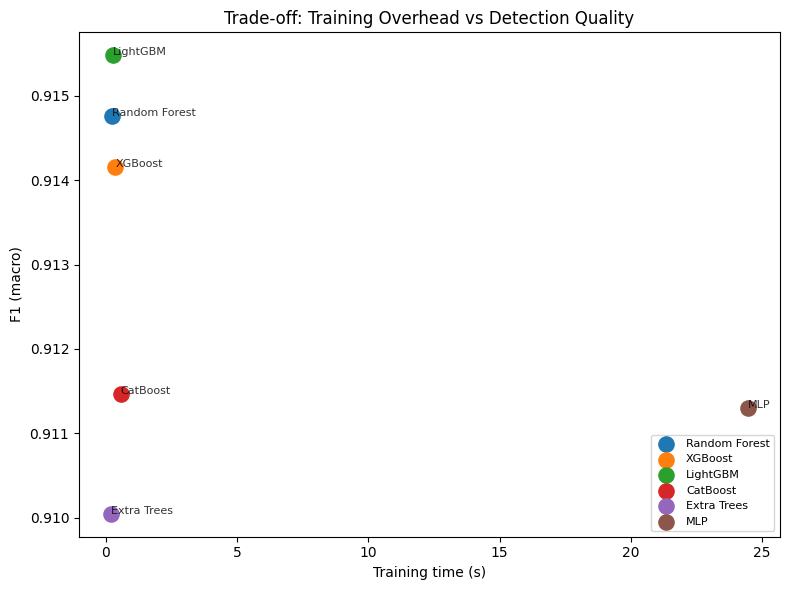

In [20]:
# Trade-off: Training time vs F1
fig, ax = plt.subplots(figsize=(8, 6))
for i, row in bench_df.iterrows():
    ax.scatter(row["train_time_sec"], row["f1_macro"], s=120, label=row["model"])
    ax.annotate(row["model"], (row["train_time_sec"], row["f1_macro"]), fontsize=8, alpha=0.8)
ax.set_xlabel("Training time (s)")
ax.set_ylabel("F1 (macro)")
ax.set_title("Trade-off: Training Overhead vs Detection Quality")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

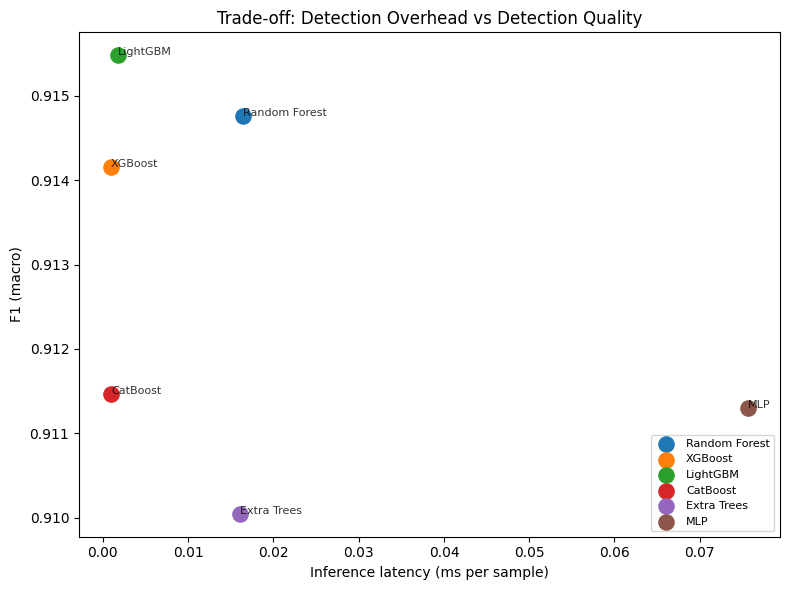

In [21]:
# Trade-off: Inference latency vs F1
fig, ax = plt.subplots(figsize=(8, 6))
for i, row in bench_df.iterrows():
    ax.scatter(row["inference_ms_per_sample"], row["f1_macro"], s=120, label=row["model"])
    ax.annotate(row["model"], (row["inference_ms_per_sample"], row["f1_macro"]), fontsize=8, alpha=0.8)
ax.set_xlabel("Inference latency (ms per sample)")
ax.set_ylabel("F1 (macro)")
ax.set_title("Trade-off: Detection Overhead vs Detection Quality")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Export Benchmark Results

In [22]:
bench_df.to_csv("fbs_benchmark_results.csv", index=False)
print("Saved fbs_benchmark_results.csv")

Saved fbs_benchmark_results.csv
